# Exploratory Data Analysis: Water Leak Detection

This notebook explores the raw sensor dataset and builds intuition for leak behavior before modeling.

## Objectives
- Load and inspect the dataset structure.
- Check data quality (types, nulls, date range).
- Compare leak vs normal operating patterns.
- Visualize distributions, temporal behavior, and correlations.
- Save a cleaned dataset for downstream notebooks.

## Analysis Flow
1. Setup and data loading.
2. Quality and label diagnostics.
3. Sensor-level and feature-level exploration.
4. Time-series and correlation analysis.
5. Clean export for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR = "../data"

# ── Figure output setup ───────────────────────────────────────────
import os

FIG_DIR = "../paper/images"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(filename, dpi=300):
    """Call this right before plt.show() in every plot cell."""
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f"Saved → {path}")


## Load Dataset
This step reads the raw CSV file and converts the timestamp column to datetime format for reliable temporal analysis.

Expected outcome: a DataFrame with 1000 rows and correctly parsed dates.

In [2]:
df = pd.read_csv(DATA_DIR+"/water_leak_detection.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print(df.shape)
df.head(10)


(6000, 7)


,Timestamp,Sensor_ID,Pressure (bar),Flow Rate (L/s),Temperature (°C),Leak Status,Burst Status
0,2024-01-07 04:30:00,S004,3.4605,110.3779,18.7203,0,0
1,2024-01-14 14:25:00,S010,2.5012,189.2489,16.9937,1,0
2,2024-01-01 18:25:00,S003,3.8443,139.2165,19.2491,0,0
3,2024-01-08 09:55:00,S005,2.6200,165.0230,17.3233,1,0
4,2024-01-19 03:20:00,S002,3.0550,125.3734,16.7781,0,0
5,2024-01-05 01:20:00,S007,3.3395,84.8203,15.0822,0,0
6,2024-01-04 01:15:00,S007,3.6406,151.4598,14.5145,0,0
7,2024-01-01 13:00:00,S010,3.7377,104.4589,10.5134,0,0
8,2024-01-06 18:05:00,S007,2.2950,133.6451,15.8786,1,0
9,2024-01-02 02:55:00,S002,3.0331,167.5688,18.3134,0,0


## Validate Schema and Completeness
Here we verify data types, check for missing values, and inspect the covered time window.

These checks help confirm that the data is ready for statistical and visual exploration.

In [3]:
print("=== DTYPES ===")
print(df.dtypes)
print("\n=== NULL VALUES ===")
print(df.isnull().sum())
print("\n=== DATE RANGE ===")
print("From :", df['Timestamp'].min())
print("To   :", df['Timestamp'].max())


=== DTYPES ===
Timestamp           datetime64[ns]
Sensor_ID                   object
Pressure (bar)             float64
Flow Rate (L/s)            float64
Temperature (°C)           float64
Leak Status                  int64
Burst Status                 int64
dtype: object

=== NULL VALUES ===
Timestamp           0
Sensor_ID           0
Pressure (bar)      0
Flow Rate (L/s)     0
Temperature (°C)    0
Leak Status         0
Burst Status        0
dtype: int64

=== DATE RANGE ===
From : 2024-01-01 00:00:00
To   : 2024-01-21 19:55:00


## Label Diagnostics: Leak vs Burst
This section checks class balance for leak labels and reviews burst events.

Because the project focuses on leak detection, burst rows are identified and later removed for a cleaner training signal.

In [4]:
print("=== LEAK STATUS ===")
print(df['Leak Status'].value_counts())
print(f"\nLeak rate : {df['Leak Status'].mean()*100:.2f}%")

print("\n=== BURST STATUS (will be removed) ===")
print(df['Burst Status'].value_counts())

print("\n=== BOTH LEAK AND BURST AT SAME TIME? ===")
both = df[(df['Leak Status']==1) & (df['Burst Status']==1)]
print(f"Rows with both : {len(both)}")


=== LEAK STATUS ===
Leak Status
0    5226
1     774
Name: count, dtype: int64

Leak rate : 12.90%

=== BURST STATUS (will be removed) ===
Burst Status
0    5590
1     410
Name: count, dtype: int64

=== BOTH LEAK AND BURST AT SAME TIME? ===
Rows with both : 0


## Sensor-Level Activity Overview
The next block summarizes how readings and leak events are distributed across sensors.

This helps identify whether events are concentrated in specific sensors or more evenly spread.

In [5]:
print("=== READINGS PER SENSOR ===")
print(df['Sensor_ID'].value_counts().sort_index())

print("\n=== LEAKS PER SENSOR ===")
print(df[df['Leak Status']==1]['Sensor_ID'].value_counts().sort_index())


=== READINGS PER SENSOR ===
Sensor_ID
S001     482
S002     622
S003     641
S004     421
S005     614
S006     671
S007     458
S008     670
S009    1001
S010     420
Name: count, dtype: int64

=== LEAKS PER SENSOR ===
Sensor_ID
S001     43
S002     69
S003    120
S004     82
S005     81
S006    108
S007     72
S008     75
S009     59
S010     65
Name: count, dtype: int64


## Statistical Comparison: Normal vs Leak
After filtering out burst events, we compare descriptive statistics between normal and leak states.

This highlights how pressure, flow, and temperature shift when leaks occur.

In [6]:
# Focus on Leak vs Normal only — ignore Burst rows
df_focus = df[df['Burst Status'] == 0].copy()

for label, name in [(0, 'Normal'), (1, 'Leak')]:
    sub = df_focus[df_focus['Leak Status'] == label]
    print(f"\n{'='*40}")
    print(f"  {name}  (n={len(sub)})")
    print(f"{'='*40}")
    print(sub[['Pressure (bar)', 'Flow Rate (L/s)', 'Temperature (°C)']].describe())



  Normal  (n=4816)
       Pressure (bar)  Flow Rate (L/s)  Temperature (°C)
count       4816.0000        4816.0000         4816.0000
mean           3.2153         124.5642           17.3895
std            0.2921          27.7191            2.7262
min            2.1734          50.5160           10.0000
25%            3.0326         107.0780           15.6593
50%            3.2219         124.3940           17.3355
75%            3.4030         141.6007           19.1241
max            4.0000         200.0000           24.9661

  Leak  (n=774)
       Pressure (bar)  Flow Rate (L/s)  Temperature (°C)
count        774.0000         774.0000          774.0000
mean           2.5316         141.3910           17.5716
std            0.4048          35.5825            2.7404
min            1.2824          67.1235           10.0117
25%            2.2189         117.2760           15.7148
50%            2.5417         141.5835           17.5550
75%            2.9077         165.7471           19

## Distribution Plots
The following histograms visualize separation between classes for key variables.

If leak and normal distributions differ clearly, these features are likely useful predictors.

Saved → ../paper/images/fig1_pressure_distribution.png


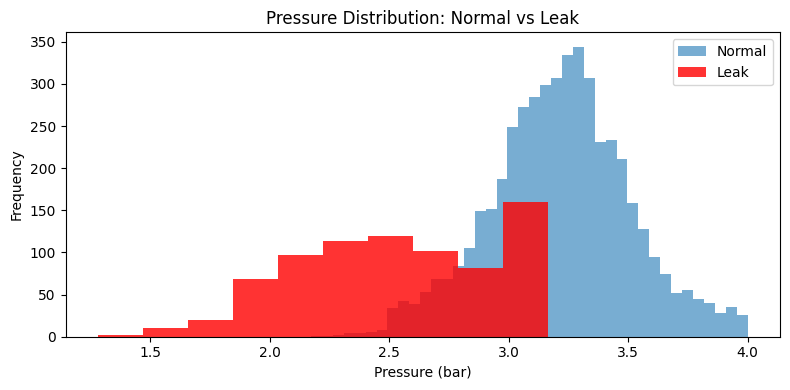

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df_focus[df_focus['Leak Status']==0]['Pressure (bar)'].plot.hist(
    bins=40, alpha=0.6, label='Normal', ax=ax)
df_focus[df_focus['Leak Status']==1]['Pressure (bar)'].plot.hist(
    bins=10, alpha=0.8, label='Leak', ax=ax, color='red')
ax.set_xlabel('Pressure (bar)')
ax.set_title('Pressure Distribution: Normal vs Leak')
ax.legend()
plt.tight_layout()
save_fig("fig1_pressure_distribution.png")
plt.show()


Saved → ../paper/images/fig2_flowrate_distribution.png


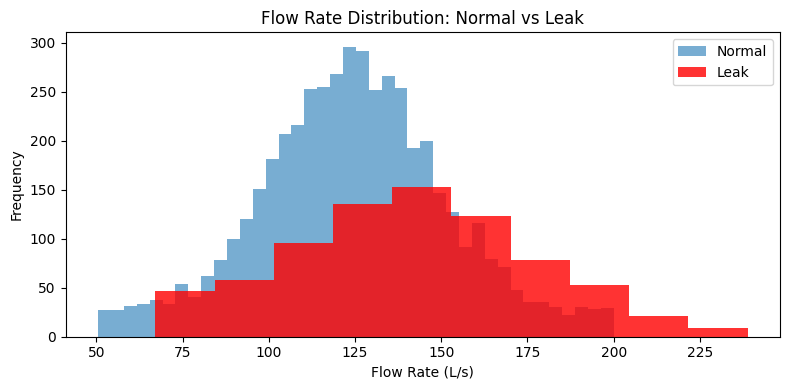

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df_focus[df_focus['Leak Status']==0]['Flow Rate (L/s)'].plot.hist(
    bins=40, alpha=0.6, label='Normal', ax=ax)
df_focus[df_focus['Leak Status']==1]['Flow Rate (L/s)'].plot.hist(
    bins=10, alpha=0.8, label='Leak', ax=ax, color='red')
ax.set_xlabel('Flow Rate (L/s)')
ax.set_title('Flow Rate Distribution: Normal vs Leak')
ax.legend()
plt.tight_layout()
save_fig("fig2_flowrate_distribution.png")
plt.show()


## Time-Series Inspection for One Sensor
A single sensor is selected to visualize temporal trajectories of pressure and flow.

Leak points are overlaid to check whether anomalies are locally visible around event timestamps.

Using sensor: S003
Saved → ../paper/images/fig3_timeseries_leak_sensor.png


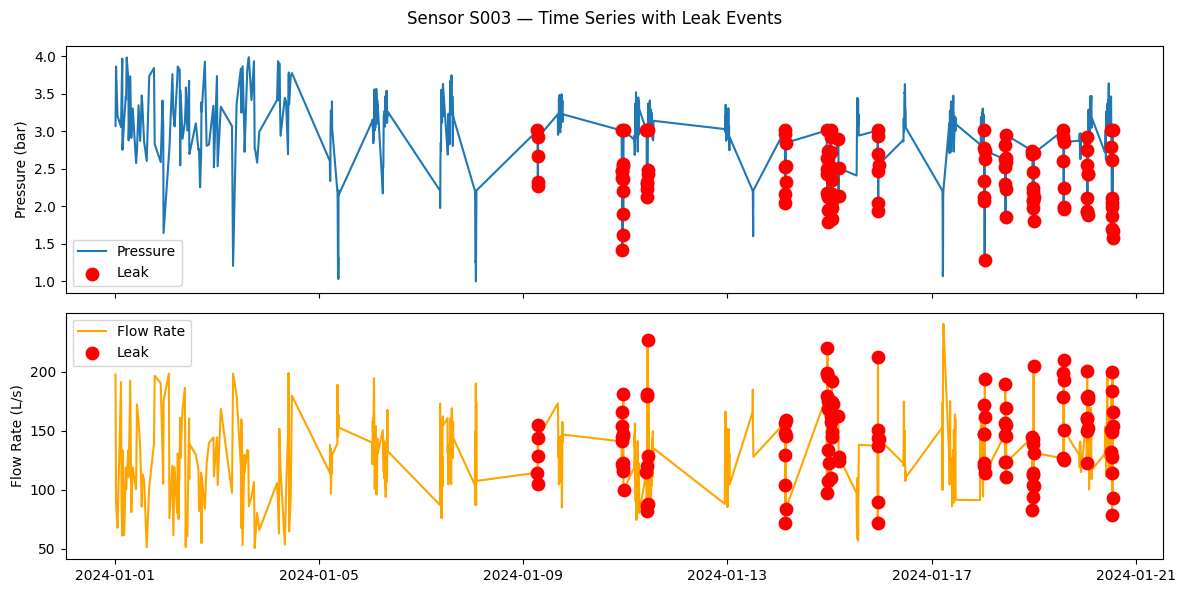

In [9]:
# Pick a sensor that has at least one leak
sensor_leaks = df[df['Leak Status']==1]['Sensor_ID'].value_counts()
chosen = sensor_leaks.index[0]
print(f"Using sensor: {chosen}")

sub = df[df['Sensor_ID'] == chosen].sort_values('Timestamp')
leaks = sub[sub['Leak Status'] == 1]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(sub['Timestamp'], sub['Pressure (bar)'], label='Pressure')
axes[0].scatter(leaks['Timestamp'], leaks['Pressure (bar)'],
                color='red', zorder=5, label='Leak', s=80)
axes[0].set_ylabel('Pressure (bar)')
axes[0].legend()

axes[1].plot(sub['Timestamp'], sub['Flow Rate (L/s)'], label='Flow Rate', color='orange')
axes[1].scatter(leaks['Timestamp'], leaks['Flow Rate (L/s)'],
                color='red', zorder=5, label='Leak', s=80)
axes[1].set_ylabel('Flow Rate (L/s)')
axes[1].legend()

plt.suptitle(f'Sensor {chosen} — Time Series with Leak Events')
plt.tight_layout()
save_fig("fig3_timeseries_leak_sensor.png")
plt.show()


## Correlation Analysis
The heatmap below summarizes linear relationships among features and the leak label.

This offers a quick signal on which variables may carry stronger predictive information.

Saved → ../paper/images/fig4_correlation_matrix.png


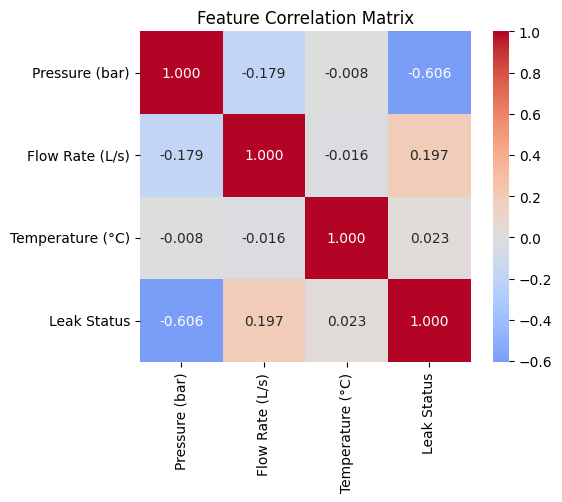

In [10]:
corr = df_focus[['Pressure (bar)', 'Flow Rate (L/s)',
                  'Temperature (°C)', 'Leak Status']].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
save_fig("fig4_correlation_matrix.png")
plt.show()


## Export Clean Dataset
Finally, burst rows are removed and the cleaned table is saved for subsequent notebooks.

Output file: data_clean.csv
This dataset is sorted by sensor and timestamp to keep temporal order consistent.

In [11]:
# Save the burst-removed version for all next notebooks
df_clean = df[df['Burst Status'] == 0].copy().drop(columns=['Burst Status'])
df_clean = df_clean.sort_values(['Sensor_ID', 'Timestamp']).reset_index(drop=True)
df_clean.to_csv(DATA_DIR+"/data_clean.csv", index=False)

print(f"Saved data/data_clean.csv")
print(f"Shape  : {df_clean.shape}")
print(f"Leaks  : {df_clean['Leak Status'].sum()}")


Saved data/data_clean.csv
Shape  : (5590, 6)
Leaks  : 774


## EDA Takeaways
- Leak events are relatively rare compared with normal operation.
- Pressure and flow patterns provide useful separation signals.
- A cleaned, burst-free dataset is now ready for feature engineering and model training.